In [24]:
import os
from langchain_openai import ChatOpenAI   # openai接口
from langchain_ollama import ChatOllama   # ollama接口

from langchain.agents import create_agent # 创建智能体
from langgraph.checkpoint.memory import InMemorySaver # 记忆
from langchain.messages import HumanMessage, AIMessage, SystemMessage


### LLM接口

In [4]:
# openai接口
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="qwen3.5-plus",             # 模型名称
    openai_api_key="sk-bvOWJIfQ8Y8IrZhzzpQZ80zSKHjWIHCkPXEgQ0H4Li5UCpUC",         # API Key
    openai_api_base="http://ai.wenmodel.com/v1", # API 地址 https://ai.wenmodel.com(https://m.tb.cn/h.ioaPOiq?tk=QGsd5gSbXZ)
    temperature=0.7,
    max_tokens=1024
)

response = llm.invoke("你是谁")
print(response.content)

你好！我是 **Qwen3.5**，阿里巴巴最新推出的通义千问大语言模型。我具备以下核心能力：

- **超长上下文**：支持 256K 上下文窗口，能精准处理数十万字的文档或长对话。
- **多语言覆盖**：流畅支持全球 100+ 语言，包括中文、英语、小语种等。
- **知识时效性**：训练数据截止至 **2026 年**，掌握最新科技、文化、生活等领域知识。
- **深度推理与专业力**：  
  ✅ 逻辑推理进阶（数学/科学问题拆解）  
  ✅ 视觉深度解析（图表、公式、实验流程图解读）  
  ✅ 代码全栈能力（生成/调试/前端页面一键实现）  
  ✅ 医疗/法律等垂直领域专业回答
- **智能体自主规划**：可自主调用工具、多步骤完成任务（如订票、数据分析）。
- **人类对齐优化**：对话更自然，指令遵循更精准，创作内容更具温度。

需要我帮你写代码、分析论文、规划旅行，还是解答专业问题？随时告诉我你的需求！ 😊


In [ ]:
# ollama接口
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="qwen3.5:0.8b",   # 必须使用支持tool-calling功能模型
    temperature=0.7,
    base_url="http://127.0.0.1:11435"
)

response = llm.invoke("你是谁")
print(response.content)

### 输入构造函数

In [23]:
# 多模态msg构造函数

import base64
from langchain.messages import HumanMessage


def encode_image(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


def build_msg(text=None, image_path=None):

    content = []

    # 添加文本
    if text:
        content.append({
            "type": "text",
            "text": text
        })

    # 添加图片
    if image_path:
        image_data = encode_image(image_path)

        content.append({
            "type": "image_url",
            "image_url": {
                "url": f"data:image/jpeg;base64,{image_data}",
                "detail": "auto"
            }
        })

    return [
        HumanMessage(content=content)
    ]

### 执行函数

In [32]:
# 流式输入

def chat_stream(agent, message, config):
    result = agent.stream(
        {"messages":message}, 
        stream_mode='updates',
        config=config
    )
    for chunk in result:
        for node_name, update in chunk.items():   
            if "messages" in update:
                for msg in update["messages"]:
                    
                    # system提示词
                    if msg.type == "system":
                       print(f"[{msg.type}] {msg.content}")  
                   
                    # user文本内容
                    if msg.type == "human":
                       print(f"[{msg.type}] {msg.content}")  
                    
                    # ai回复
                    if msg.type == "ai":
                        if msg.content:
                            print(f"[{msg.type}] {msg.content}")
                        
                        if hasattr(msg, 'tool_calls') and msg.tool_calls:
                            calls = [tc['name'] for tc in msg.tool_calls]
                            print(f"请求调用: {calls}")
    
                    # tool工具回复
                    if msg.type == "tool":
                        print(f"[调用工具 {msg.name}]")
                        print(f"[{msg.type}] {msg.content}") 


# 为什么需要多 Agent
单个 Agent 的问题：  
·system_prompt 太长会导致模型注意力分散  
·工具太多会增加模型选择工具的出错概率  
·不同类型的任务需要不同的专业知识和行为风格  
·多 Agent 的方案：每个 Agent 专注于一个领域，通过协作完成复杂任务。

# 1. 方式1：子agent作为工具
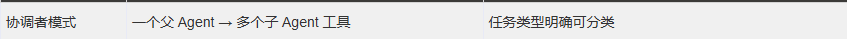

## 1.1 子agent1：天气专家

In [16]:
# 子 Agent 1：天气专家

from langchain.tools import tool
import requests

@tool
def get_weather(longitude: str, latitude: str):
    '''
    功能:使用Open-Meteo查询指定坐标的天气情况。
    Args:
        longitude:经度，例如 "52.520011"
        latitude:纬度，例如 "13.410004"
    return:
        指定坐标未来逐小时的温度和相对湿度摘要。
    '''
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,relative_humidity_2m",
        "timezone": "auto",
        "forecast_days": 1
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        return data
    except requests.exceptions.RequestException as e:
        return f"天气接口请求失败：{str(e)}"


data = get_weather.invoke({
    "latitude": "52.520011",
    "longitude": "13.410004"
})
print(data)

{'latitude': 52.52, 'longitude': 13.419998, 'generationtime_ms': 0.03898143768310547, 'utc_offset_seconds': 7200, 'timezone': 'Europe/Berlin', 'timezone_abbreviation': 'GMT+2', 'elevation': 38.0, 'hourly_units': {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%'}, 'hourly': {'time': ['2026-07-14T00:00', '2026-07-14T01:00', '2026-07-14T02:00', '2026-07-14T03:00', '2026-07-14T04:00', '2026-07-14T05:00', '2026-07-14T06:00', '2026-07-14T07:00', '2026-07-14T08:00', '2026-07-14T09:00', '2026-07-14T10:00', '2026-07-14T11:00', '2026-07-14T12:00', '2026-07-14T13:00', '2026-07-14T14:00', '2026-07-14T15:00', '2026-07-14T16:00', '2026-07-14T17:00', '2026-07-14T18:00', '2026-07-14T19:00', '2026-07-14T20:00', '2026-07-14T21:00', '2026-07-14T22:00', '2026-07-14T23:00'], 'temperature_2m': [20.7, 19.7, 18.9, 18.2, 17.6, 17.2, 17.1, 17.5, 18.2, 19.5, 20.4, 21.8, 23.3, 24.6, 25.9, 26.7, 27.2, 27.7, 27.5, 27.0, 26.1, 24.9, 22.9, 21.4], 'relative_humidity_2m': [69, 74, 77, 82, 86, 89, 

In [19]:
weather_agent = create_agent(
    model=llm,
    tools=[get_weather],
    name="weather_expert",  # 名字用于标识和日志
    system_prompt="你是天气专家，专门回答天气相关问题。回答要简洁。",
)

### 1.2 子agent2：市场价格专家

In [17]:
# 子 agnet 2： 市场价格专家
import requests
from bs4 import BeautifulSoup

@tool
def get_price():
    '''
    功能:查询商务部柑橘价格数据。
    return:
        一段时间的柑橘价格。
    '''
    price_id = "23543271"

    page_url = (
        f"https://cif.mofcom.gov.cn/cif/html/mobile/dataDetail.html?id={price_id}"
    )
    api_url = (
        "https://cif.mofcom.gov.cn/cif/phone/dataDetail.fhtml"
    )
    headers = {
        "User-Agent": "Mozilla/5.0",
        "Referer": page_url,
        "X-Requested-With": "XMLHttpRequest",
    }


    # 请求接口
    response = requests.post(
        api_url,
        data={
            "id": price_id,
            "startDate": "",
            "endDate": ""
        },
        headers=headers,
        timeout=30
    )

    response.raise_for_status()
    data = response.json()

    # 提取价格
    rows = []
    for item in data.get("dataList", []):
        rows.append(
            {
                "date": item["DATADATE"],
                "price": float(item["DATA"])
            }
        )
    return rows
    

data = get_price.invoke({})
print(data)

[{'date': '2025-07-18', 'price': 7.31}, {'date': '2025-07-25', 'price': 7.37}, {'date': '2025-08-01', 'price': 7.29}, {'date': '2025-08-08', 'price': 7.2}, {'date': '2025-08-15', 'price': 7.18}, {'date': '2025-08-22', 'price': 7.17}, {'date': '2025-08-29', 'price': 6.86}, {'date': '2025-09-05', 'price': 6.76}, {'date': '2025-09-12', 'price': 6.62}, {'date': '2025-09-19', 'price': 6.6}, {'date': '2025-09-26', 'price': 6.53}, {'date': '2025-10-03', 'price': 6.38}, {'date': '2025-10-10', 'price': 6.36}, {'date': '2025-10-17', 'price': 6.19}, {'date': '2025-10-24', 'price': 6.36}, {'date': '2025-10-31', 'price': 6.2}, {'date': '2025-11-07', 'price': 6.12}, {'date': '2025-11-14', 'price': 6.04}, {'date': '2025-11-21', 'price': 6.01}, {'date': '2025-11-28', 'price': 6.0}, {'date': '2025-12-05', 'price': 5.9}, {'date': '2025-12-12', 'price': 5.9}, {'date': '2025-12-19', 'price': 5.9}, {'date': '2025-12-26', 'price': 6.03}, {'date': '2026-01-02', 'price': 6.0}, {'date': '2026-01-09', 'price': 

In [20]:
price_agent = create_agent(
    model=llm,
    tools=[get_price],
    name="price_expert",  # 名字用于标识和日志
    system_prompt="你是市场专家，专门回答市场价格相关问题。回答要简洁。",
)

### 1.3 父agent：协调者，将子 Agent 作为工具注册

In [25]:
@tool
def ask_weather_expert(question: str):
    '''
    功能：向天气专家咨询天气相关问题。
    Args:
        question: 关于天气的问题
    return:
        天气agent的回复
    '''
    result = weather_agent.invoke(
        {"messages": [HumanMessage(content=question)]}
    )
    return result["messages"][-1].content


@tool
def ask_price_expert(question: str):
    '''
    功能：向市场专家咨询价格相关问题。
    Args:
        question: 关于价格的问题
    return:
        价格agent的回复
    '''
    result = price_agent.invoke(
        {"messages": [HumanMessage(content=question)]}
    )
    return result["messages"][-1].content

In [28]:
# 创建记忆
checkpointer = InMemorySaver()

# 创建合作智能体
coordinator = create_agent(
    model=llm,
    tools=[ask_weather_expert, ask_price_expert],
    checkpointer=checkpointer,
    system_prompt="""你是协调助手。根据用户问题选择合适的专家：
- 天气相关问题 → 使用 ask_weather_expert
- 价格相关问题 → 使用 ask_price_expert
- 如果同时涉及多个领域，依次咨询各个专家""",
)


# 创建config
config = {"configurable": {"thread_id": "demo-001"}}

In [33]:
# 父智能体
msg = build_msg(text="查询今日武汉天气，并根据柑橘市场价格与天气情况，预估未来3天的价格变化", image_path=None)
chat_stream(coordinator, msg, config)

请求调用: ['ask_weather_expert', 'ask_price_expert']
[调用工具 ask_weather_expert]
[tool] **武汉今日天气概况：**

- **温度**：30.1°C ~ 37.9°C
- **最高温**：约14:00-15:00，37.9°C
- **最低温**：约06:00，30.1°C
- **湿度**：44% ~ 84%（中午较低，早晚较高）

天气炎热，注意防暑降温！
[调用工具 ask_price_expert]
[tool] 根据最新柑橘价格数据（截至2026年7月3日，价格5.68元/公斤），近期价格呈现**缓慢上涨趋势**：

| 日期 | 价格（元/公斤） |
|------|----------------|
| 6月5日 | 5.42 |
| 6月12日 | 5.53 |
| 6月19日 | 5.63 |
| 6月26日 | 5.66 |
| 7月3日 | 5.68 |

**未来3天价格预估：**
- **趋势**：预计继续小幅上涨或保持平稳
- **预估价格区间**：5.68-5.75元/公斤
- **影响因素**：夏季供应相对紧张，需求稳定

⚠️ 注：以上预估基于历史价格趋势，未纳入实时天气数据。如遇极端天气（暴雨、高温等），价格可能出现波动。建议关注当地气象及市场动态。
[ai] 根据查询结果，为您整理如下信息：

## 🌤️ 武汉今日天气情况

| 指标 | 数值 |
|------|------|
| **温度范围** | 30.1°C ~ 37.9°C |
| **最高温时段** | 14:00-15:00（约37.9°C） |
| **最低温时段** | 06:00左右（约30.1°C） |
| **湿度范围** | 44% ~ 84% |

⚠️ **提醒**：天气炎热，请注意防暑降温！

---

## 🍊 柑橘价格分析与未来3天预估

### 近期价格走势
| 日期 | 价格（元/公斤） |
|------|----------------|
| 6月5日 | 5.42 |
| 6月12日 | 5.53 |
| 6月19日 | 5.63 |
| 6月26日 | 5.66 |
| 7月3日 | 5.68 |

### 未来3天价格预估
- **趋势**：继续小幅上

In [37]:
# 查看对话状态
state = coordinator.get_state(config)

print(f"下一步: {state.next}")  # () 表示空闲
print(f"消息数: {len(state.values.get('messages', []))}")

# 查看对话历史
for msg in state.values.get("messages", []):
    print(f"  [{msg.type}] {str(msg.content)[:500]}")

下一步: ()
消息数: 12
  [human] [{'type': 'text', 'text': '查询今日武汉天气，并根据柑橘市场价格与天气情况，预估未来3天的价格变化'}]
  [ai] 
  [human] [{'type': 'text', 'text': '查询今日武汉天气，并根据柑橘市场价格与天气情况，预估未来3天的价格变化'}]
  [ai] 
  [tool] **武汉今日天气概况：**

- **温度**：30.1°C ~ 37.9°C
- **最高温**：约14:00-15:00，37.9°C
- **最低温**：约06:00，30.1°C
- **湿度**：44% ~ 84%（中午较低，早晚较高）

天气炎热，注意防暑降温！
  [tool] 根据最新柑橘价格数据（截至2026年7月3日，价格5.68元/公斤），近期价格呈现**缓慢上涨趋势**：

| 日期 | 价格（元/公斤） |
|------|----------------|
| 6月5日 | 5.42 |
| 6月12日 | 5.53 |
| 6月19日 | 5.63 |
| 6月26日 | 5.66 |
| 7月3日 | 5.68 |

**未来3天价格预估：**
- **趋势**：预计继续小幅上涨或保持平稳
- **预估价格区间**：5.68-5.75元/公斤
- **影响因素**：夏季供应相对紧张，需求稳定

⚠️ 注：以上预估基于历史价格趋势，未纳入实时天气数据。如遇极端天气（暴雨、高温等），价格可能出现波动。建议关注当地气象及市场动态。
  [ai] 根据查询结果，为您整理如下信息：

## 🌤️ 武汉今日天气情况

| 指标 | 数值 |
|------|------|
| **温度范围** | 30.1°C ~ 37.9°C |
| **最高温时段** | 14:00-15:00（约37.9°C） |
| **最低温时段** | 06:00左右（约30.1°C） |
| **湿度范围** | 44% ~ 84% |

⚠️ **提醒**：天气炎热，请注意防暑降温！

---

## 🍊 柑橘价格分析与未来3天预估

### 近期价格走势
| 日期 | 价格（元/公斤） |
|------|----------------|
| 6月5日 | 5.42 |
| 6月

# 2. 通过中间件实现agent路由